In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# Load dataset
df = pd.read_csv('wine.csv')
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Target
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [3]:
# Split features and target
X = df.drop('Target', axis=1)
y = df['Target']

In [4]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
explained_variance

array([5.30677631e-01, 1.46228109e-01, 1.13398377e-01, 8.42962318e-02,
       4.75855700e-02, 3.30018239e-02, 2.63542821e-02, 1.33240107e-02,
       5.13396430e-03, 5.86053905e-34])

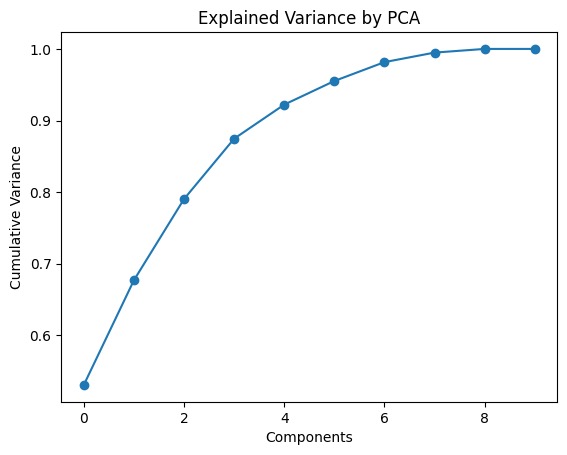

In [6]:
# Variance Plot
plt.figure()
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Components')
plt.ylabel('Cumulative Variance')
plt.title('Explained Variance by PCA')
plt.show()

In [7]:
# Reduce to 2 Components
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

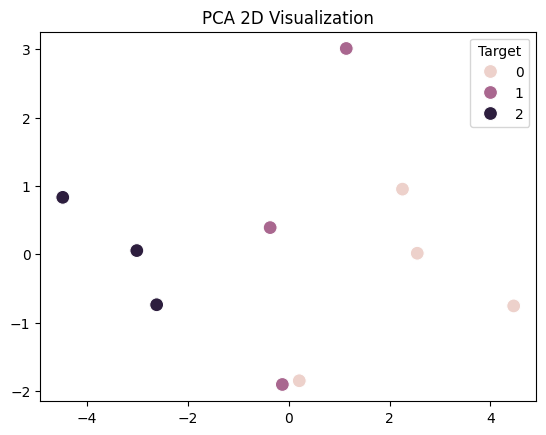

In [8]:
# 2D Visualization
plt.figure()
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=y, s=100)
plt.title('PCA 2D Visualization')
plt.show()

In [9]:
print('Explained variance by 2 components:', sum(pca2.explained_variance_ratio_))

Explained variance by 2 components: 0.6769057398251892
